# Chapter 2: Data and Sampling Distributions

This notebook reproduces the Python code from Chapter 2 of *Practical Statistics for Data Scientists* (2nd Edition) by Peter Bruce, Andrew Bruce, and Peter Gedeck.

The chapter discusses how data is sampled from a population and why sampling still matters in the era of big data. It covers random sampling and bias, the sampling distribution of a statistic, the bootstrap, confidence intervals, and several common probability distributions such as the normal, t, binomial, Poisson, exponential, and Weibull distributions.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
from scipy import stats
from sklearn.utils import resample

import seaborn as sns
import matplotlib.pyplot as plt

DATA = Path('data')

## 1. Random Sampling and Sample Bias

A **sample** is a subset of data taken from a larger dataset, called the **population**. The goal is usually to learn something about the population from the sample.

- **Random sampling**: each member of the population has an equal chance of being chosen. This is the best way to obtain a sample that is representative of the population.
- **Stratified sampling**: the population is divided into groups (strata), and random samples are taken from each group. This ensures that important subgroups are represented.
- **Sample bias**: when the sample systematically differs from the population it is meant to represent. A famous example is the 1936 Literary Digest poll, which predicted the wrong US presidential winner because its sample was drawn mostly from wealthier people.
- **Bias** in general refers to systematic error, as opposed to random error that comes from chance.

Notation: the mean of a sample is written as x̄ (x-bar), while the mean of the population is written as μ (mu).

Even in the era of big data, **data quality often matters more than data quantity**. A smaller, carefully drawn random sample can be more useful than a huge dataset with hidden bias.

## 2. Selection Bias

**Selection bias** happens when data is selected in a way that leads to a misleading conclusion, consciously or unconsciously.

- **Data snooping**: extensively searching through data until something "interesting" appears. If you look hard enough, random patterns will eventually look meaningful.
- **Vast search effect**: the bias that comes from repeatedly fitting many models or asking many questions of a large dataset.
- **Regression to the mean**: in repeated measurements, extreme observations tend to be followed by more average ones. For example, a rookie athlete with an exceptional first season often performs worse in the second season, partly because the first season included a lot of luck.

Ways to reduce selection bias include specifying a hypothesis before looking at the data, using holdout sets, and using target shuffling (permutation) to check whether a result could have happened by chance.

## 3. Sampling Distribution of a Statistic

A **sample statistic** is a value calculated from a sample, such as the sample mean. If we draw many samples and compute the statistic each time, the values will vary. The distribution of these values is called the **sampling distribution**.

- The **data distribution** is the distribution of individual values in a dataset.
- The **sampling distribution** is the distribution of a sample statistic over many samples.

The sampling distribution of the mean is narrower and more bell-shaped than the data distribution, and it gets narrower as the sample size increases.

**Central Limit Theorem (CLT)**: the means drawn from many samples will follow a roughly normal distribution, even if the original data is not normal, as long as the sample size is large enough.

**Standard error**: the standard deviation of a sampling distribution. It can be estimated as s / √n, where s is the sample standard deviation and n is the sample size. A larger sample size gives a smaller standard error.

The example uses annual incomes of loan applicants to Lending Club.

In [2]:
loans_income = pd.read_csv(DATA / 'loans_income.csv').squeeze('columns')
loans_income.head()

0     67000
1     52000
2    100000
3     78762
4     37041
Name: x, dtype: int64

In [3]:
sample_data = pd.DataFrame({
    'income': loans_income.sample(1000),
    'type': 'Data',
})

sample_mean_05 = pd.DataFrame({
    'income': [loans_income.sample(5).mean() for _ in range(1000)],
    'type': 'Mean of 5',
})

sample_mean_20 = pd.DataFrame({
    'income': [loans_income.sample(20).mean() for _ in range(1000)],
    'type': 'Mean of 20',
})

results = pd.concat([sample_data, sample_mean_05, sample_mean_20])
results.head()

,income,type
47692,130000.0,Data
234,105000.0,Data
1593,45000.0,Data
10406,80000.0,Data
8579,44000.0,Data


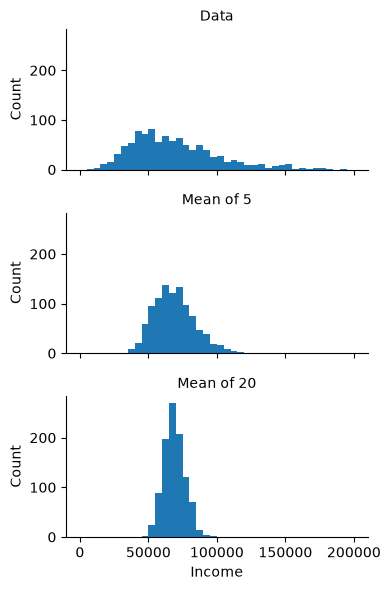

In [4]:
g = sns.FacetGrid(results, col='type', col_wrap=1, height=2, aspect=2)
g.map(plt.hist, 'income', range=[0, 200000], bins=40)
g.set_axis_labels('Income', 'Count')
g.set_titles('{col_name}')
plt.tight_layout()
plt.show()

The top panel shows the original data, which is right-skewed. The distribution of the mean of 5 values is narrower and more bell-shaped, and the distribution of the mean of 20 values is even narrower. This illustrates the Central Limit Theorem and shows that a larger sample size reduces the standard error.

## 4. The Bootstrap

The **bootstrap** is a simple and powerful way to estimate the sampling distribution of a statistic without relying on mathematical formulas or assumptions about the population.

The idea is to draw additional samples **with replacement** from the sample itself, then recalculate the statistic for each resample. The procedure:
1. Draw a sample value, record it, and put it back.
2. Repeat n times to form one bootstrap resample.
3. Calculate the statistic (e.g., the median) for the resample.
4. Repeat steps 1 to 3 many times (e.g., 1,000 times).
5. Use the collected results to estimate the standard error, construct confidence intervals, or assess bias.

The bootstrap does not create new data and does not fix a small sample. It only tells us how much a statistic would vary if we drew more samples from a population similar to our sample.

Below, the bootstrap is used to estimate the standard error of the median income.

In [5]:
results = []
for nrepeat in range(1000):
    sample = resample(loans_income)
    results.append(sample.median())
results = pd.Series(results)

print('Bootstrap Statistics:')
print(f'original: {loans_income.median()}')
print(f'bias: {results.mean() - loans_income.median()}')
print(f'std. error: {results.std()}')

Bootstrap Statistics:
original: 62000.0
bias: -63.33400000000256
std. error: 195.93651155555608


The bias is small, which means the bootstrap median is close to the original median. The standard error tells us how much the median would typically vary from sample to sample.

## 5. Confidence Intervals

A single estimate (a point estimate) does not show how uncertain it is. A **confidence interval** presents an estimate as a range instead.

- **Confidence level**: the percentage of confidence intervals, built the same way from the same population, that are expected to contain the true value (e.g., 90% or 95%).
- **Interval endpoints**: the lower and upper bounds of the interval.

A bootstrap confidence interval can be built as follows:
1. Draw many bootstrap resamples and compute the statistic for each.
2. For a 90% interval, cut off 5% from each end of the distribution of results.
3. The remaining range is the 90% bootstrap confidence interval.

A higher confidence level gives a wider interval, while a larger sample gives a narrower interval.

Below, a 90% confidence interval is computed for the mean income, based on a sample of only 20 loan applicants.

In [6]:
print('Population mean:', loans_income.mean())

np.random.seed(seed=3)
sample20 = resample(loans_income, n_samples=20, replace=False)
print('Sample of 20 mean:', sample20.mean())

Population mean: 68760.51844
Sample of 20 mean: 55734.1


90% confidence interval: [43212.45, 70233.43999999999]


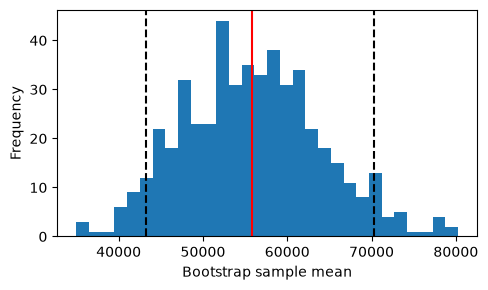

In [7]:
results = []
for nrepeat in range(500):
    sample = resample(sample20)
    results.append(sample.mean())
results = pd.Series(results)

confidence_interval = list(results.quantile([0.05, 0.95]))
print('90% confidence interval:', confidence_interval)

ax = results.plot.hist(bins=30, figsize=(5, 3))
ax.axvline(confidence_interval[0], color='black', linestyle='--')
ax.axvline(confidence_interval[1], color='black', linestyle='--')
ax.axvline(results.mean(), color='red')
ax.set_xlabel('Bootstrap sample mean')
plt.tight_layout()
plt.show()

## 6. Normal Distribution

The **normal distribution** (bell curve, Gaussian distribution) is symmetric around its mean.
- About 68% of the data lies within 1 standard deviation of the mean.
- About 95% lies within 2 standard deviations.
- About 99.7% lies within 3 standard deviations.

The normal distribution is important historically because many sampling distributions (such as the distribution of sample means) are approximately normal, thanks to the Central Limit Theorem. However, raw data itself is often **not** normally distributed.

### Standard Normal and QQ-Plots

- **Standardization (z-score)**: subtract the mean and divide by the standard deviation. The result shows how many standard deviations a value is from the mean.
- **Standard normal distribution**: a normal distribution with mean 0 and standard deviation 1.
- **QQ-plot**: plots the z-scores of the sample against the theoretical quantiles of a normal distribution. If the points fall close to the diagonal line, the data is approximately normal.

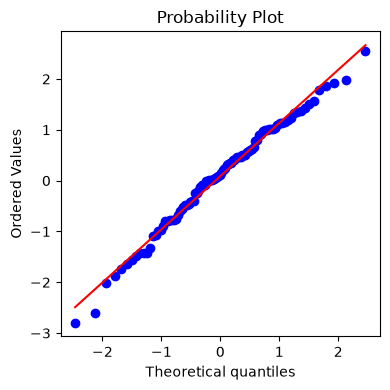

In [8]:
fig, ax = plt.subplots(figsize=(4, 4))
norm_sample = stats.norm.rvs(size=100)
stats.probplot(norm_sample, plot=ax)
plt.tight_layout()
plt.show()

Since this sample was generated from a normal distribution, the points follow the diagonal line closely.

## 7. Long-Tailed Distributions

Real-world data is often not normally distributed. Many datasets have **long tails**, meaning extreme values occur more often than a normal distribution would predict. A distribution can also be **skewed**, with one tail longer than the other.

Ignoring long tails can lead to underestimating the probability of extreme events, which is a serious problem in areas like finance and risk management.

The example below shows a QQ-plot of the daily log returns of Netflix (NFLX) stock.

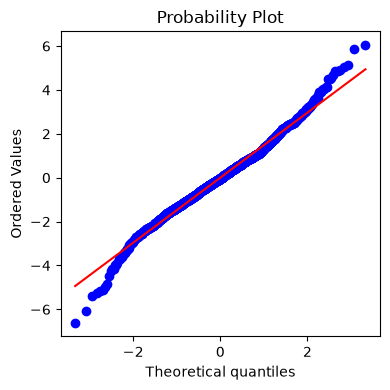

In [9]:
sp500_px = pd.read_csv(DATA / 'sp500_data.csv.gz')

nflx = sp500_px.NFLX
nflx = np.diff(np.log(nflx[nflx > 0]))

fig, ax = plt.subplots(figsize=(4, 4))
stats.probplot(nflx, plot=ax)
plt.tight_layout()
plt.show()

In contrast to the previous QQ-plot, the points at both ends curve away from the line: low values fall far below it and high values far above it. This means Netflix returns have much longer tails than a normal distribution, so extreme daily returns are more common than the normal distribution would suggest.

## 8. Student's t-Distribution

The **t-distribution** is a normally shaped distribution with thicker tails. It is a family of distributions whose shape depends on the **degrees of freedom**, which is related to the sample size. The larger the sample, the closer the t-distribution is to the normal distribution.

It was developed by W. S. Gosset (publishing as "Student") and is widely used to describe the distribution of sample means and differences between sample means, especially when the sample size is small. It is the basis for the t-test and for confidence intervals in classical statistics.

## 9. Binomial Distribution

Many outcomes are binary: yes/no, buy/don't buy, click/no click.

- **Trial**: an event with a discrete outcome (e.g., a coin flip).
- **Success**: the outcome of interest, often coded as 1.
- **Binomial distribution**: the distribution of the number of successes in n independent trials, each with the same probability of success p.

The mean of a binomial distribution is n × p, and the variance is n × p × (1 - p). With enough trials (and p not too close to 0 or 1), the binomial distribution is approximately normal.

Example: if the probability of a click converting to a sale is 0.1, what is the probability of exactly 2 sales in 5 clicks? And of 2 or fewer sales?

In [10]:
print('P(exactly 2 sales):', stats.binom.pmf(2, n=5, p=0.1))
print('P(2 or fewer sales):', stats.binom.cdf(2, n=5, p=0.1))

P(exactly 2 sales): 0.07289999999999992
P(2 or fewer sales): 0.99144


`pmf` (probability mass function) gives the probability of an exact number of successes, while `cdf` (cumulative distribution function) gives the probability of that number or fewer.

## 10. Chi-Square Distribution

The **chi-square distribution** measures how far observed counts deviate from expected counts under a null hypothesis (for example, the assumption that two categorical variables are independent).

The chi-square statistic is calculated from the squared differences between observed and expected counts, scaled by the expected counts. A low value means the observed data fits the expected pattern well; a high value means there is a large deviation. The distribution of this statistic under repeated random sampling is the chi-square distribution, and it is used in tests of independence and goodness of fit (covered in Chapter 3).

## 11. F-Distribution

The **F-distribution** is used to compare variation between groups to variation within groups. For example, when comparing several treatment groups, the F-statistic is the ratio of the variability among group means to the variability within the groups.

A large F-statistic suggests the group means differ more than would be expected by chance. The F-distribution is the basis for ANOVA (analysis of variance) and is also used in regression to assess model fit (covered in Chapters 3 and 4).

## 12. Poisson and Related Distributions

Many processes produce events at a constant average rate, such as visitors arriving at a website or cars arriving at a toll booth.

- **Lambda (λ)**: the average rate of events per unit of time or space.
- **Poisson distribution**: the distribution of the number of events in a fixed interval, given rate λ. Its mean and variance are both equal to λ.
- **Exponential distribution**: the distribution of the time or distance between events, using the same rate λ.
- **Weibull distribution**: a generalization of the exponential distribution in which the event rate can change over time. It is commonly used in reliability and failure analysis. Its shape parameter β controls whether the failure rate increases (β > 1) or decreases (β < 1) over time, and its scale parameter η is the characteristic life.

The examples below generate random samples from each distribution.

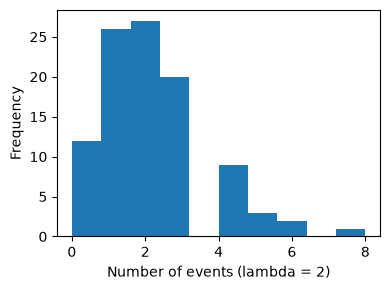

In [11]:
sample = stats.poisson.rvs(2, size=100)

ax = pd.Series(sample).plot.hist(figsize=(4, 3))
ax.set_xlabel('Number of events (lambda = 2)')
plt.tight_layout()
plt.show()

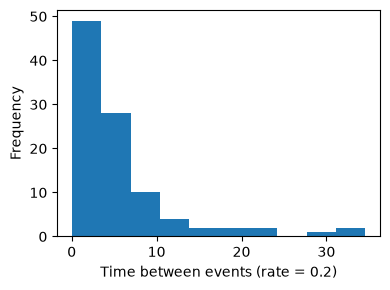

In [12]:
sample = stats.expon.rvs(scale=1 / 0.2, size=100)

ax = pd.Series(sample).plot.hist(figsize=(4, 3))
ax.set_xlabel('Time between events (rate = 0.2)')
plt.tight_layout()
plt.show()

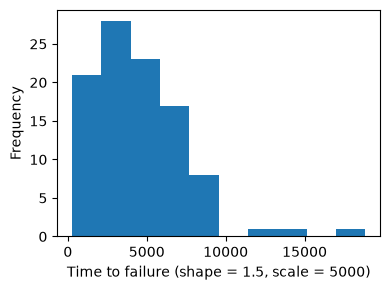

In [13]:
sample = stats.weibull_min.rvs(1.5, scale=5000, size=100)

ax = pd.Series(sample).plot.hist(figsize=(4, 3))
ax.set_xlabel('Time to failure (shape = 1.5, scale = 5000)')
plt.tight_layout()
plt.show()

The Poisson sample is discrete and centered around λ = 2. The exponential sample is strongly right-skewed: short waiting times are common and long ones are rare. The Weibull sample with shape 1.5 has an increasing failure rate, so its distribution is less skewed than the exponential.

## Summary

This chapter explains how data relates to the population it comes from, and how to measure the uncertainty of estimates.

Key takeaways:
- Random sampling helps produce samples that represent the population. Sample bias and selection bias can lead to misleading conclusions, and data quality often matters more than data size.
- The sampling distribution describes how a statistic varies across samples. By the Central Limit Theorem, sample means tend to be normally distributed, and the standard error decreases as the sample size grows.
- The bootstrap estimates the sampling distribution by resampling the data with replacement, without needing formulas or distributional assumptions.
- Confidence intervals express an estimate as a range, and can be built easily with the bootstrap.
- The normal distribution is central to classical statistics, but real data often has long tails. QQ-plots help check whether data is normally distributed.
- Other common distributions include the t-distribution (small-sample inference), binomial (counts of successes), chi-square (count data and independence), F (comparing group variation), and Poisson, exponential, and Weibull (event rates and waiting times).